# DSA 107 — Lab 1: Environment and first notebook

**Week 1 · w/c 30 September 2026** · paired with DSA 101 lecture week 1

**Name:** Orhan Unser **Student ID:** 26022121141

---

### What you will produce

A runnable Colab notebook, pushed to your own GitHub repository, that loads a dataset, answers four questions about it, and draws one labelled figure.

### Before you start

Run the setup cell below. If any import fails, run
`!pip install pandas matplotlib seaborn scikit-learn` in a new cell and try again.


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.2.3 | numpy 2.1.3


## 1. Load the data

`pd.read_csv` accepts a URL as happily as a filename. Load the penguins dataset into a DataFrame called `penguins`.

In [33]:
penguins = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv")

# TODO: show the first five rows
penguins.head()
# What if we only want to see the first 3 rows?
# penguins.head(3)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## 2. How big is it, and what is in it?

Three commands answer almost every first question about a dataset:

- `.shape` — rows and columns
- `.info()` — column names, types, and how many non-missing values each has
- `.describe()` — summary statistics for the numeric columns

In [34]:
# Check dataset dimensions and column data types
print(penguins.shape)
penguins.info()

(344, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [35]:
# Summary statistics for numerical columns
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### Missing values

`.isna()` gives a True/False table the same shape as the data. Summing it down the columns counts the missing values in each.

In [36]:
penguins.isna().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


**Q1.** How many penguins are in the dataset, and how many columns describe each one?

**Q2.** Which column has the most missing values, and how many? Suggest one plausible reason a field measurement might be missing.

Answer1. The dataset contains 344 penguins (rows) and 7 columns describing each penguin.

Answer2. The `sex` column has the most missing values with 11 missing rows. A simple reason could be that it is hard to tell a penguin's sex just by looking at it in the wild without blood tests or detailed exams.

## 3. Selecting and filtering

A single column is `df["name"]`. Several columns is `df[["a", "b"]]` — note the double brackets. Rows are chosen with a condition: `df[df["col"] > 5]`.

In [37]:
penguins[['species', 'island', 'body_mass_g']].head()
#Let's try different lenghts of tables
#penguins[["species","island", "body_mass_g"]].head(3)
#Also let's check the last 3 rows to see the bottom of the table with .tail()
#penguins[['species', 'island', 'body_mass_g']].tail(3)

,species,island,body_mass_g
0,Adelie,Torgersen,3750.0
1,Adelie,Torgersen,3800.0
2,Adelie,Torgersen,3250.0
3,Adelie,Torgersen,NaN
4,Adelie,Torgersen,3450.0


In [38]:
gentoo = penguins[penguins['species'] == 'Gentoo']
print(f"Number of Gentoo penguins: {len(gentoo)}")
#Quick check for adelie penguins
#adelie = penguins[penguins['species'] == 'Adelie']
#print(f"Number of Adelie penguins: {len(adelie)}")

Number of Gentoo penguins: 124


**Q3.** How many Gentoo penguins are there? What fraction of the dataset is that?

Answer3. There are 124 Gentoo penguins. That is about 0.36 (or 36%) of the entire dataset.

In [39]:
fraction = len(gentoo) / len(penguins)
print(f"Fraction of Gentoo penguins: {fraction:.3f} (or {fraction * 100:.1f}%)")

Fraction of Gentoo penguins: 0.360 (or 36.0%)


## 4. Your first figure

A scatter plot of two numeric columns, coloured by a third categorical one. Every figure in this course needs axis labels and a title — a plot without them is not a finished piece of work.

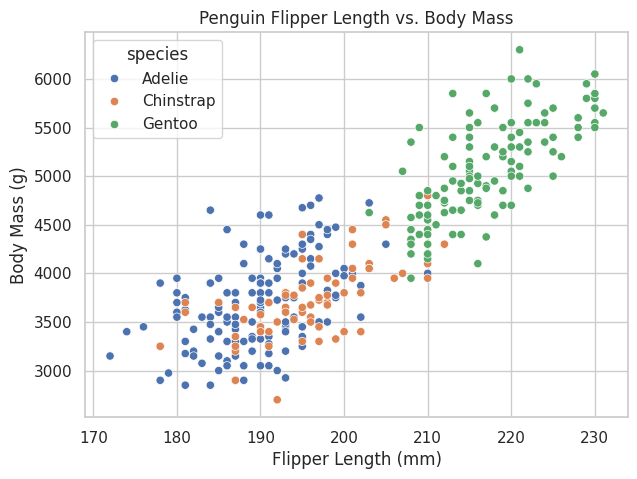

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g', hue='species', ax=ax)
ax.set_title('Penguin Flipper Length vs. Body Mass')
ax.set_xlabel('Flipper Length (mm)')
ax.set_ylabel('Body Mass (g)')
plt.show()

**Q4.** Describe the relationship in two sentences. Does it hold within every species, or only across all three together? What would you check next?


Answer4. The scatter plot shows that as flipper length increases, body mass also gets bigger, which means there is a positive relationship between them. This pattern is visible overall and also seems to hold within each species, with Gentoo penguins generally having both the longest flippers and the highest mass. Next, I would like to check if the sex of the penguins affects this size difference.

## 5. Push to GitHub

1. Create a repository named `dsa107-labs` on GitHub (public is fine).
2. In Colab: **File → Save a copy in GitHub**, choose that repository.
3. Paste the resulting link in the cell below.

**Repository link:** https://github.com/orhanunser/dsa107-labs.git

---

## Submission checklist

- [X] Every cell runs top to bottom without error (Runtime → Restart and run all)
- [X] Every written answer is filled in — a plot with no reading of it scores zero on interpretation
- [X] Notebook saved as `Lab01_Firstname_Lastname.ipynb`
- [X] Report exported as `Lab01_Firstname_Lastname.pdf`
- [X] If you used an AI assistant, the log is attached as described in the course AI policy

Submit both files through MS Teams.

AI logs:

1) **print the shape, then call .info()**

I will modify the cell to print the shape of the penguins DataFrame and display its info.
The shape and info for the dataset have been printed successfully. Now, let's complete the next TODO in cell cd52876d by computing the summary statistics for the numeric columns using .describe().
Let's work on cell 730db04a now. I will add the code to count the missing values in each column.

2) **count the missing values in each column**

I am modifying cell 730db04a to compute and display the count of missing values for each column of the penguins DataFrame.
The missing values have been counted. Next, I will modify cell 3fa53947 to select and display only the species, island, and body_mass_g columns for the first five rows.

3) **show only species, island and body_mass_g, first five rows**

I am modifying cell 3fa53947 to select and display the first five rows of the species, island, and body_mass_g columns from the penguins DataFrame.

4) **make a DataFrame called gentoo holding only the Gentoo penguins,**

I am modifying cell 5cf2fcf3 to filter the dataset and create the gentoo DataFrame, then output how many Gentoo penguins there are.

6) **compute and print the fraction**

I will modify cell 23e89ca5 to calculate the fraction of Gentoo penguins in the dataset and display it.

7) **scatter plot of flipper_length_mm against body_mass_g,scatter plot of flipper_length_mm against body_mass_g**

I am modifying cell 1e2fcc85 to create the scatter plot of flipper length against body mass, colored by species, complete with proper axis labels and a title.


